# Lookup tables in two and three dimensions: search, layout, batches and deployment

Engineering models carry their measured behaviour as gridded tables: a heat pump's COP from its
datasheet, a motor's efficiency map, a wing's aerodynamic coefficients. `interp.interpolant` on a
tuple of grids makes each one a tensor-product spline, evaluated in generated C.

This notebook builds three such tables, checks them against SciPy, then looks at what decides
their speed and size:

- how the cell of a point is found;
- whether the table is stored as per-cell polynomials or as B-spline coefficients with local
  bases;
- what a batch of points costs.

It ends with the two ways to ship a table in C: baked into the source, or passed in by the caller
at run time, here from a C `main`.

| Scaly feature | Where |
| --- | --- |
| `interp.interpolant(grids, values, kind=...)`, one kind per axis | three tables |
| `search=` (`"uniform"`, `"bucket"`, `"binary"`, `"count"`, `"auto"`) | finding the cell |
| `strategy="pp"` and `"basis"` | per-cell polynomials or local bases |
| a batch `f(X)`, `X` of shape `(N, D)`, and reverse mode through it | batches |
| an `Expr` table as a Function input; the header's layout comment | deployment |

In [1]:
import subprocess
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
from scipy.interpolate import NdBSpline, RegularGridInterpolator, make_interp_spline

import plotstyle
import scaly as sc
from scaly import interp
from scaly.codegen import write_module
from scaly.codegen.toolchain import find_c_compiler

plotstyle.use()
GENERATED = Path.cwd().parent / "generated" / "interp" / "lookup_tables_nd"
rng = np.random.default_rng(0)


def tensor_reference(grid, values, degrees):
  """SciPy's tensor-product spline: a not-a-knot fit of the given degree along each axis in turn."""
  coeffs, knots = values, []
  for axis, (g, k) in enumerate(zip(grid, degrees, strict=True)):
    fit = make_interp_spline(g, coeffs, k=k, axis=axis)
    coeffs, knots = np.moveaxis(fit.c, 0, axis), [*knots, fit.t]
  return NdBSpline(tuple(knots), coeffs, tuple(degrees))


def batch_function(f, n, name, gradient=False):
  """``f`` at a batch of ``n`` points, and its gradients, as one Function."""
  d = f.ndim

  @sc.function(sc.L("X", (n, d)), output=sc.G("y", "g") if gradient else "y", name=name)
  def batch(X):
    y = f(X)
    return (y, sc.gradient(y.sum(), X)) if gradient else y

  return batch


def points_in(grid, n):
  return np.column_stack([rng.uniform(g[0], g[-1], n) for g in grid])

## Three tables

- **The heat pump's COP** against outdoor and supply temperature, on a 9 x 8 datasheet grid
  every 5 K: a fraction of the Carnot COP that falls slowly with the supply temperature.
  Bicubic.
- **The motor's efficiency** against speed and torque: mechanical power over power plus losses
  (a constant, copper losses in the torque squared, eddy-current and friction losses in the speed). The
  10 x 11 grid is denser at low speed and torque, where the efficiency climbs from zero.
  Bilinear and bicubic.
- **The wing's lift coefficient** against angle of attack, Mach number and flap angle: the thin-
  aerofoil slope $2\pi$ scaled by the Prandtl-Glauert factor $1/\sqrt{1 - M^2}$, softened past
  a stall at 14°, on a 12 x 8 x 5 grid. Cubic in the first two axes and linear in the flap,
  which has only five values.

Each is checked at 10 000 random points against SciPy's tensor-product spline (`NdBSpline` of
per-axis `make_interp_spline` fits), values and gradients, the gradients by reverse mode through
the batch.

In [2]:
# A heat pump's COP against outdoor and supply temperature [C]: a 9 x 8 datasheet grid.
cop_grid = (np.arange(-20.0, 21.0, 5.0), np.arange(25.0, 61.0, 5.0))
hot, cold = cop_grid[1][None, :] + 278.15, cop_grid[0][:, None] + 268.15
cop_values = (0.5 - 0.002 * (cop_grid[1][None, :] - 25.0)) * hot / (hot - cold)

# A motor's efficiency against speed [rpm] and torque [Nm], denser where it changes fast.
speed = np.array([0.0, 250.0, 500.0, 1000.0, 1500.0, 2000.0, 3000.0, 4000.0, 5000.0, 6000.0])
torque = np.array([0.0, 5.0, 10.0, 20.0, 40.0, 60.0, 80.0, 100.0, 130.0, 160.0, 200.0])
w, tq = np.meshgrid(speed * np.pi / 30.0, torque, indexing="ij")
power = w * tq
losses = 120.0 + 0.12 * tq**2 + 0.0015 * w**2 + 0.4 * w  # constant, copper, eddy-current, friction [W]
eta_values = np.where(power > 0, power / (power + losses), 0.0)
motor_grid = (speed, torque)

# A wing's lift coefficient against angle of attack [deg], Mach number and flap angle [deg]:
# thin-aerofoil slope with Prandtl-Glauert compressibility, softened past stall.
alpha = np.array([-10.0, -6.0, -3.0, 0.0, 3.0, 6.0, 9.0, 12.0, 14.0, 16.0, 18.0, 20.0])
mach = np.linspace(0.2, 0.9, 8)
flap = np.linspace(-20.0, 20.0, 5)
a, m, dl = np.meshgrid(np.radians(alpha), mach, np.radians(flap), indexing="ij")
stall = np.radians(14.0)
effective = np.where(a > stall, stall + 0.4 * (a - stall) - 1.5 * (a - stall) ** 2, a)
cl_values = (2.0 * np.pi * effective + 1.8 * dl) / np.sqrt(1.0 - m**2)
aero_grid = (alpha, mach, flap)

tables = {
  "COP, bicubic": (interp.interpolant(cop_grid, cop_values, kind="cubic", name="cop"), cop_grid, cop_values, (3, 3)),
  "motor, bilinear": (interp.interpolant(motor_grid, eta_values, kind="linear", name="motor_lin"), motor_grid, eta_values, (1, 1)),
  "motor, bicubic": (interp.interpolant(motor_grid, eta_values, kind="cubic", name="motor_cub"), motor_grid, eta_values, (3, 3)),
  "C_L, cubic x cubic x linear": (interp.interpolant(aero_grid, cl_values, kind=("cubic", "cubic", "linear"), name="aero"), aero_grid, cl_values, (3, 3, 1)),
}
N_CHECK = 10_000
agreement = {}
for label, (f, grid, values, degrees) in tables.items():
  pts = points_in(grid, N_CHECK)
  y, g = batch_function(f, N_CHECK, f"nd_check_{f.name}", gradient=True)(pts)
  ref = tensor_reference(grid, values, degrees)
  ref_grad = np.column_stack([ref(pts, nu=tuple(int(i == j) for i in range(len(grid)))) for j in range(len(grid))])
  agreement[label] = (np.abs(y - ref(pts)).max() / np.abs(values).max(), np.abs(g - ref_grad).max() / np.abs(ref_grad).max())
  searches = ", ".join(ax.search for ax in f.axes)
  print(f"{label:28s} value {agreement[label][0]:.1e}, gradient {agreement[label][1]:.1e} (relative); search {searches}; {f.strategy}")
rgi = RegularGridInterpolator(cop_grid, cop_values, method="cubic_legacy")
print(f"COP against RegularGridInterpolator(method='cubic_legacy'): {np.abs(rgi(pts := points_in(cop_grid, 1000)) - batch_function(tables['COP, bicubic'][0], 1000, 'nd_cop_rgi')(pts)).max():.1e}")

COP, bicubic                 value 4.4e-16, gradient 1.1e-15 (relative); search binary, binary; pp
motor, bilinear              value 4.6e-16, gradient 3.5e-16 (relative); search binary, binary; pp
motor, bicubic               value 6.9e-16, gradient 7.9e-16 (relative); search binary, binary; pp
C_L, cubic x cubic x linear  value 6.7e-16, gradient 1.2e-15 (relative); search binary, binary, binary; pp


COP against RegularGridInterpolator(method='cubic_legacy'): 3.6e-15


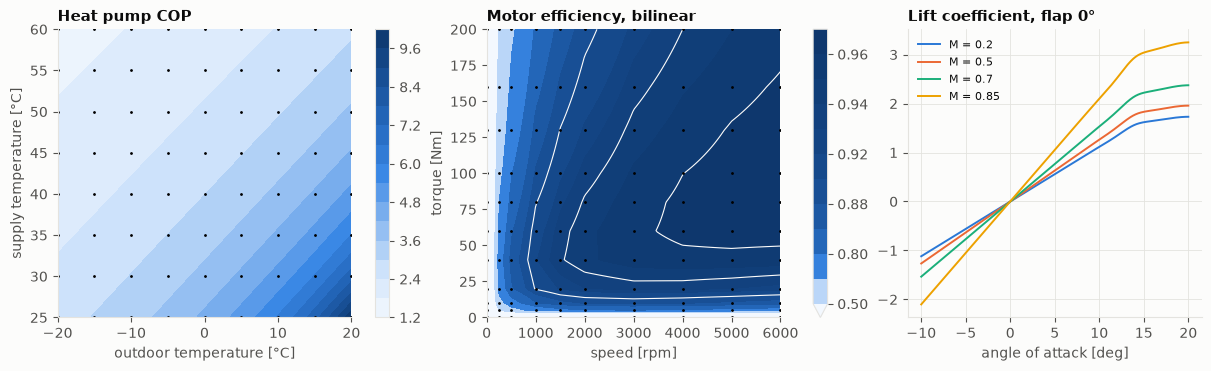

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(12, 3.6))
fine = [np.linspace(g[0], g[-1], 160) for g in cop_grid]
F = np.stack(np.meshgrid(*fine, indexing="ij"), axis=-1).reshape(-1, 2)
cop_f = batch_function(tables["COP, bicubic"][0], F.shape[0], "nd_cop_plot")(F).reshape(160, 160)
c0 = axes[0].contourf(fine[0], fine[1], cop_f.T, levels=14, cmap=plotstyle.BLUES)
axes[0].plot(*np.meshgrid(*cop_grid, indexing="ij"), "k.", ms=2)
fig.colorbar(c0, ax=axes[0])
axes[0].set_xlabel("outdoor temperature [°C]")
axes[0].set_ylabel("supply temperature [°C]")
axes[0].set_title("Heat pump COP")
fine = [np.linspace(g[0], g[-1], 200) for g in motor_grid]
F = np.stack(np.meshgrid(*fine, indexing="ij"), axis=-1).reshape(-1, 2)
eta_f = batch_function(tables["motor, bilinear"][0], F.shape[0], "nd_motor_plot")(F).reshape(200, 200)
levels = [0.5, 0.7, 0.8, 0.85, 0.88, 0.9, 0.92, 0.93, 0.94, 0.95, 0.96, 0.97]
c1 = axes[1].contourf(fine[0], fine[1], eta_f.T, levels=levels, cmap=plotstyle.BLUES, extend="min")
axes[1].contour(fine[0], fine[1], eta_f.T, levels=[0.9, 0.94, 0.96], colors=plotstyle.SURFACE, linewidths=0.8)
axes[1].plot(*np.meshgrid(*motor_grid, indexing="ij"), "k.", ms=2)
fig.colorbar(c1, ax=axes[1])
axes[1].set_xlabel("speed [rpm]")
axes[1].set_ylabel("torque [Nm]")
axes[1].set_title("Motor efficiency, bilinear")
a_fine = np.linspace(-10.0, 20.0, 300)
for i, m_value in enumerate((0.2, 0.5, 0.7, 0.85)):
  P = np.column_stack([a_fine, np.full(300, m_value), np.zeros(300)])
  axes[2].plot(a_fine, batch_function(tables["C_L, cubic x cubic x linear"][0], 300, f"nd_aero_plot_{i}")(P), lw=1.4, label=f"M = {m_value}")
axes[2].set_xlabel("angle of attack [deg]")
axes[2].set_title("Lift coefficient, flap 0°")
axes[2].legend(fontsize=8)
plt.show()

In [4]:
dense_motor = np.stack(np.meshgrid(np.linspace(0.0, 6000.0, 301), np.linspace(0.0, 200.0, 201), indexing="ij"), axis=-1).reshape(-1, 2)
eta_lin = batch_function(tables["motor, bilinear"][0], dense_motor.shape[0], "nd_motor_lin_dense")(dense_motor)
eta_cubic = batch_function(tables["motor, bicubic"][0], dense_motor.shape[0], "nd_motor_cub_dense")(dense_motor)
w_d, t_d = dense_motor[:, 0] * np.pi / 30.0, dense_motor[:, 1]
eta_true = np.where(w_d * t_d > 0, w_d * t_d / (w_d * t_d + 120.0 + 0.12 * t_d**2 + 0.0015 * w_d**2 + 0.4 * w_d), 0.0)
print(f"data: {eta_values.min():.3f} to {eta_values.max():.4f}")
for name, eta in (("bilinear", eta_lin), ("bicubic", eta_cubic)):
  print(f"{name:9s}: {eta.min():+.3f} to {eta.max():.4f}; error against the loss model: max {np.abs(eta - eta_true).max():.3f}, mean {np.abs(eta - eta_true).mean():.4f}")
edge = (dense_motor[:, 0] <= 250.0) | (dense_motor[:, 1] <= 5.0)  # the first cell along either axis
print(f"away from the first cells: bilinear max error {np.abs(eta_lin - eta_true)[~edge].max():.3f}, bicubic {np.abs(eta_cubic - eta_true)[~edge].max():.3f}")

data: 0.000 to 0.9667
bilinear : -0.000 to 0.9667; error against the loss model: max 0.297, mean 0.0115
bicubic  : -0.000 to 0.9669; error against the loss model: max 0.191, mean 0.0069
away from the first cells: bilinear max error 0.034, bicubic 0.031


All four agree with SciPy to $10^{-15}$ relative, gradients included. The COP table also equals
`RegularGridInterpolator(method="cubic_legacy")`, SciPy's per-axis not-a-knot fit, to
$4 \times 10^{-15}$. `"auto"` chose the binary search on every axis, since none has more than 32
cells, and per-cell polynomials.

The motor map shows the limit of a table. Both interpolants miss the loss model by 0.2 to 0.3 in
the first cell along either axis, where the efficiency climbs from 0 to about a half: no
interpolant recovers what the grid does not resolve. Away from those cells the bilinear table
misses by at most 0.034 and the bicubic by 0.031; over the whole map they miss by 0.012 and 0.007 on average. The
bilinear one never leaves the data's range. The bicubic exceeds the largest value by
$2 \times 10^{-4}$.

## Finding the cell

Evaluating a table first finds the cell of each coordinate. `search=` picks the method per axis:

- `"uniform"`: a floor, and one correction against the cell's own edges; for uniform grids only;
- `"bucket"`: a uniform bucket index, the bucket's first cell from a table, then a few compares;
- `"binary"`: branch-free halvings;
- `"count"`: a branch-free count of the edges passed;
- `"auto"`: binary up to 32 cells, then bucket, uniform or binary by what the grid allows.

The two layouts of the next section also enter. The cost is measured here as nanoseconds per
point on batches of $10^6$ random points: one call, one loop in C.

In [5]:
N = 1_000_000


def ns_per_point(f, n, name, reps=5):
  fn = batch_function(f, n, name)
  pts = points_in(tuple(ax.edges for ax in f.axes), n)
  fn(pts)
  best = min(_timed(fn, pts) for _ in range(reps))
  return 1e9 * best / n


def _timed(fn, pts):
  t0 = time.perf_counter()
  fn(pts)
  return time.perf_counter() - t0


timing_rows = []
for label, grid, values, kinds, searches in (
  ("COP 9 x 8, uniform", cop_grid, cop_values, "cubic", ("uniform", "bucket", "binary")),
  ("motor 10 x 11, non-uniform", motor_grid, eta_values, "linear", ("bucket", "binary", "count")),
  ("C_L 12 x 8 x 5", aero_grid, cl_values, ("cubic", "cubic", "linear"), ("bucket", "binary")),
):
  for strategy in ("pp", "basis"):
    for search in searches:
      f = interp.interpolant(grid, values, kind=kinds, search=search, strategy=strategy)
      timing_rows.append((label, strategy, search, ns_per_point(f, N, f"nd_time_{len(timing_rows)}")))
    auto = interp.interpolant(grid, values, kind=kinds)
    if strategy == auto.strategy:
      timing_rows.append((label, strategy, "auto: " + "/".join(ax.search for ax in auto.axes), ns_per_point(auto, N, f"nd_time_{len(timing_rows)}")))
print(f"{'table':28s} {'strategy':8s} {'search':28s} ns/point")
for row in timing_rows:
  print(f"{row[0]:28s} {row[1]:8s} {row[2]:28s} {row[3]:6.1f}")

table                        strategy search                       ns/point
COP 9 x 8, uniform           pp       uniform                         6.2
COP 9 x 8, uniform           pp       bucket                          6.2
COP 9 x 8, uniform           pp       binary                          4.4
COP 9 x 8, uniform           pp       auto: binary/binary             4.4
COP 9 x 8, uniform           basis    uniform                        11.0
COP 9 x 8, uniform           basis    bucket                         11.0
COP 9 x 8, uniform           basis    binary                          8.7
motor 10 x 11, non-uniform   pp       bucket                          3.5
motor 10 x 11, non-uniform   pp       binary                          2.9
motor 10 x 11, non-uniform   pp       count                           2.3
motor 10 x 11, non-uniform   pp       auto: binary/binary             2.9
motor 10 x 11, non-uniform   basis    bucket                          5.2
motor 10 x 11, non-uniform   basis  

On these small tables the binary search is the fastest of the three the uniform COP grid allows,
with the uniform search about 40 % slower: a floor, a clamp and a correcting compare cost more
than three or four halvings over 8 or 9 cells. On the 10 x 11 motor table the count search,
which `"auto"` never picks, beats binary by about 0.5 ns a point. At random points in a batch its
ten independent compares vectorize. For one point called repeatedly, what the library's
`auto` rule was tuned on, count never won. `auto` stays within about a quarter of the
fastest choice everywhere here.

The pair `pairs/lut_eval` compares such batches with CasADi. Its three tables (a 1-D cubic on
1 000 non-uniform sites, a 64 x 64 bicubic with Hessians, a 20³ trilinear), at 10 000 random
points and every node each, with gradients, take 0.8 ms in Scaly against 44 ms through CasADi's virtual machine
and 28 ms compiled (`examples/interp/README.md` holds the table).

## Per-cell polynomials or local bases

`strategy="pp"` stores, for every cell, the Taylor coefficients of its polynomial at the cell's
centre, and evaluates them by nested Horner: $\prod_d (k_d + 1)$ numbers per cell. `"basis"`
stores the B-spline coefficients once, fetches the $\prod_d (k_d + 1)$ that touch the cell, and
combines them with each axis's $k + 1$ local basis functions. `"auto"` takes `pp` while its table
fits in 4 MB or is the smaller of the two. The generated C sizes (every table is a constant in
the source) show the trade.

In [6]:
layout_rows = []
for label, (f, grid, values, degrees) in tables.items():
  for strategy in ("pp", "basis"):
    g = interp.interpolant(grid, values, kind=tuple({1: "linear", 3: "cubic"}[k] for k in degrees), strategy=strategy)
    fn = batch_function(g, 1, f"nd_layout_{g.name}_{strategy}_{len(layout_rows)}")
    source = write_module(fn, GENERATED / "layout" / f"{len(layout_rows)}").source
    layout_rows.append((label, strategy, len(source) / 1e3, len(source.splitlines())))
for row in layout_rows:
  print(f"{row[0]:28s} {row[1]:6s} {row[2]:8.1f} kB of C, {row[3]:5d} lines")

COP, bicubic                 pp         31.1 kB of C,    96 lines
COP, bicubic                 basis      11.1 kB of C,   117 lines
motor, bilinear              pp         11.1 kB of C,    89 lines
motor, bilinear              basis       6.7 kB of C,   116 lines
motor, bicubic               pp         46.8 kB of C,   102 lines
motor, bicubic               basis      13.6 kB of C,   123 lines
C_L, cubic x cubic x linear  pp        294.5 kB of C,   111 lines
C_L, cubic x cubic x linear  basis      22.2 kB of C,   152 lines


Per-cell polynomials cost 1.7 to 13 times the C of local bases. The 3-D table stores 32
numbers for each of 468 cells (the cubic axes carry two outer cells each, which hold the linear
extrapolation), 295 kB of source against 22 kB. They are also 1.4 to 2 times as fast (previous
section). `"auto"` keeps them up to a 4 MB table: past that the source and its compile time grow
faster than the speed repays. The interpolation benchmarks found per-cell polynomials still
faster at 8 MB, at 14 times the C.

## Batches and their derivatives

Called with a batch `X` of shape `(N, D)`, a table is one mapped call of the point's graph,
`vmap` in Scaly's IR: a loop in C whose body is the single-point code, whatever `N` is. Reverse mode through
the map gives each point's gradient, since each value depends on its own row only. The COP
table's value and gradient, at three batch sizes:

In [7]:
cop = tables["COP, bicubic"][0]
sizes = (10, 1_000, 100_000)
batch_rows = []
for n in sizes:
  fn = batch_function(cop, n, f"nd_batch_{n}", gradient=True)
  module = write_module(fn, GENERATED / "batch" / f"n{n}")
  pts = points_in(cop_grid, n)
  fn(pts)
  batch_rows.append((n, len(module.source.splitlines()), 1e9 * min(_timed(fn, pts) for _ in range(5)) / n))
for n, lines, ns in batch_rows:
  print(f"N = {n:>7d}: {lines} lines of C, {ns:.1f} ns per point for the value and the gradient")

N =      10: 222 lines of C, 400.0 ns per point for the value and the gradient
N =    1000: 222 lines of C, 17.5 ns per point for the value and the gradient
N =  100000: 222 lines of C, 12.4 ns per point for the value and the gradient


The source is the same 222 lines at every size. Per point, the value and the gradient cost 13 ns
at $10^5$ points. At 10 points the Python call around the C, a few microseconds, dominates.

## Deployment: the table in the code, or the table as an input

A table can be baked into the code, its coefficients constants in the source. Or it can be an
input, when the data change more often than the code: a calibration, a fleet of units with their
own maps, a table identified online. With an `Expr` table the fit becomes part of the graph. For
the bicubic that is a constant linear map applied to the input at run time, so the same compiled
code serves any table. The header states each multi-axis buffer's shape and order in a comment.

In [8]:
@sc.function(sc.L("x", 2), output=sc.G("cop", "dcop_dx"), name="cop_baked")
def cop_baked(x):
  y = cop(x)
  return y, sc.gradient(y, x)


@sc.function(sc.L("x", 2), sc.L("table", cop_values.shape), output=sc.G("cop", "dcop_dx"), name="cop_input")
def cop_input(x, table):
  y = interp.interpolant(cop_grid, table, kind="cubic")(x)
  return y, sc.gradient(y, x)


baked = write_module(cop_baked, GENERATED / "baked")
given = write_module(cop_input, GENERATED / "input")
print(f"baked in: {len(baked.source.splitlines())} lines; as an input: {len(given.source.splitlines())} lines")
print("\n".join(line for line in given.header.splitlines() if "typedef" in line and "cop_input_table_t" in line or "row-major" in line))

baked in: 152 lines; as an input: 241 lines
typedef struct { SCALY_ALIGNAS(16) double data[72]; } cop_input_table_t;  // 9 x 8, row-major (C order)


In [9]:
# A C caller: it reads a recalibrated table (the datasheet's values times 0.95) and three points from
# stdin, calls cop_input, and prints the COP and its gradient.
main_c = r"""
#include <stdio.h>
#include "cop_input.h"
int main(void) {
  static cop_input_workspace_t workspace;
  cop_input_table_t table;
  for (int i = 0; i < 72; ++i) if (scanf("%lf", &table.data[i]) != 1) return 2;
  for (int k = 0; k < 3; ++k) {
    cop_input_x_t x;
    cop_input_cop_t y;
    cop_input_dcop_dx_t g;
    if (scanf("%lf %lf", &x.data[0], &x.data[1]) != 2) return 3;
    int err = cop_input_call(&x, &table, &y, &g, &workspace);
    if (err) return err;
    printf("%.17g %.17g %.17g\n", y.data[0], g.data[0], g.data[1]);
  }
  return 0;
}
"""
(GENERATED / "input" / "main.c").write_text(main_c)
exe = GENERATED / "input" / "cop_main"
subprocess.run([find_c_compiler().cc, "-O2", "-std=c11", "main.c", given.source_name, "-lm", "-o", exe.name], cwd=GENERATED / "input", check=True)
recalibrated = 0.95 * cop_values
queries = np.array([[-7.0, 35.0], [2.0, 45.0], [12.5, 57.0]])
stdin = " ".join(repr(float(v)) for v in recalibrated.reshape(-1)) + " " + " ".join(repr(float(v)) for v in queries.reshape(-1))
c_out = np.array([[float(t) for t in line.split()] for line in subprocess.run([str(exe)], input=stdin, capture_output=True, text=True, check=True).stdout.splitlines()])
jit_out = np.array([np.concatenate([np.ravel(o) for o in cop_input(q, recalibrated)]) for q in queries])
c_vs_jit = float(np.abs(c_out - jit_out).max())
print(c_out)
print(f"C main against the JIT: {c_vs_jit:.1e}; against 0.95 x the baked table: {np.abs(c_out[:, 0] - 0.95 * np.array([float(cop_baked(q)[0]) for q in queries])).max():.1e}")

[[ 2.74607418  0.05281235 -0.05545349]
 [ 2.66444136  0.0502657  -0.05360067]
 [ 2.54721611  0.04674055 -0.05076153]]
C main against the JIT: 0.0e+00; against 0.95 x the baked table: 1.3e-15


The table as an input costs 89 lines more than the baked one: the fit, applied to whatever the
caller passes. The C `main` feeds it a table recalibrated to 95 % and gets exactly what the JIT
gives for the same table, to the last bit. The result is 0.95 times the baked table's to
$10^{-15}$, since the fit is linear in the data. The files, `main.c` included, are in
`examples/generated/interp/lookup_tables_nd/`.

## Checks

In [10]:
assert all(v < 1e-13 and g < 1e-12 for v, g in agreement.values())
assert eta_lin.min() >= -1e-15 and eta_lin.max() <= eta_values.max() + 1e-15  # bilinear stays in the data's range
assert 0.0 < eta_cubic.max() - eta_values.max() < 1e-3  # bicubic leaves it, barely
assert np.abs(eta_cubic - eta_true).mean() < np.abs(eta_lin - eta_true).mean()
times = {(r[0], r[1], r[2].split(":")[0]): r[3] for r in timing_rows}
for label in {r[0] for r in timing_rows}:
  best = min(t for (lab, _, _), t in times.items() if lab == label)
  assert min(t for (lab, _, s), t in times.items() if lab == label and s == "auto") <= 1.3 * best, label
assert len({lines for _, lines, _ in batch_rows}) == 1  # the C does not grow with the batch
assert c_vs_jit < 1e-14
print("all 6 checks passed")

all 6 checks passed
